# Лабораторная работа №7
## *Декодирование DTMF сигналов*
по курсу Цифровая обработка сигналов

**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Рыбин Сергей Витальевич  
**выполнил:** Янкин Иван Ю.  
**группа:** М4121

## Импорт необходимых библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import math

## Параметры DTMF системы

In [ ]:
# DTMF частоты (Гц)
low_freqs = [697, 770, 852, 941]      # Низкочастотная группа
high_freqs = [1209, 1336, 1477, 1633] # Высокочастотная группа

# Соответствие частот символам
dtmf_map = {
    (697, 1209): '1',
    (697, 1336): '2',
    (697, 1477): '3',
    (697, 1633): 'A',
    (770, 1209): '4',
    (770, 1336): '5',
    (770, 1477): '6',
    (770, 1633): 'B',
    (852, 1209): '7',
    (852, 1336): '8',
    (852, 1477): '9',
    (852, 1633): 'C',
    (941, 1209): '*',
    (941, 1336): '0',
    (941, 1477): '#',
    (941, 1633): 'D'
}

# Параметры сигнала
symbol_duration = 0.2    # 200 мс
pause_duration = 0.1     # 100 мс
segment_duration = symbol_duration + pause_duration  # 300 мс

file_path = '/content/DTMF_Lab15.wav'

## Реализация алгоритма Герцеля

In [ ]:
def goertzel(samples, sample_rate, frequencies):
    """
    Алгоритм Герцеля для вычисления мощности сигнала на заданных частотах

    Parameters:
    samples - массив отсчетов сигнала
    sample_rate - частота дискретизации
    frequencies - список частот для анализа

    Returns:
    powers - список мощностей для каждой частоты
    """
    N = len(samples)
    powers = []

    for f in frequencies:
        k = int(0.5 + (f * N) / sample_rate)

        w = 2.0 * math.pi * k / N
        cos_w = math.cos(w)
        sin_w = math.sin(w)
        coeff = 2.0 * cos_w

        q1 = 0.0
        q2 = 0.0

        for i in range(N):
            q0 = coeff * q1 - q2 + samples[i]
            q2 = q1
            q1 = q0

        real = q1 - q2 * cos_w
        imag = q2 * sin_w
        power = real**2 + imag**2
        powers.append(power)

    return powers

## Функция для декодирования DTMF символа

In [ ]:
def decode_dtmf_symbol(segment, sample_rate, threshold_ratio=0.1):
    """
    Декодирование одного DTMF символа из сегмента сигнала

    Parameters:
    segment - сегмент сигнала
    sample_rate - частота дискретизации
    threshold_ratio - отношение порога к максимальной мощности

    Returns:
    symbol - распознанный символ или None если символ не распознан
    """
    # Вычисление мощностей для всех DTMF частот
    low_powers = goertzel(segment, sample_rate, low_freqs)
    high_powers = goertzel(segment, sample_rate, high_freqs)

    # Поиск максимальных мощностей в каждой группе
    max_low_power = max(low_powers)
    max_high_power = max(high_powers)

    # Определение порога
    threshold = max(max_low_power, max_high_power) * threshold_ratio

    # Поиск частот, превышающих порог
    low_freq_indices = [i for i, power in enumerate(low_powers) if power > threshold]
    high_freq_indices = [i for i, power in enumerate(high_powers) if power > threshold]

    # Если найдена ровно одна частота в каждой группе
    if len(low_freq_indices) == 1 and len(high_freq_indices) == 1:
        low_freq = low_freqs[low_freq_indices[0]]
        high_freq = high_freqs[high_freq_indices[0]]

        # Поиск символа в карте соответствия
        symbol = dtmf_map.get((low_freq, high_freq))
        return symbol

    return None

## Основная функция декодирования

In [ ]:
def decode_dtmf_signal(filename, threshold_ratio=0.1):
    """
    Полное декодирование DTMF сигнала из WAV файла

    Parameters:
    filename - имя WAV файла
    threshold_ratio - отношение порога к максимальной мощности

    Returns:
    sequence - распознанная последовательность символов
    """
    sample_rate, data = wavfile.read(filename)

    if len(data.shape) > 1:
        data = data.mean(axis=1)

    # Нормализация данных
    data = data.astype(np.float32) / np.max(np.abs(data))

    # Вычисление длительностей в отсчетах
    symbol_length = int(symbol_duration * sample_rate)
    segment_length = int(segment_duration * sample_rate)

    sequence = []

    for i in range(0, len(data) - symbol_length, segment_length):
        segment = data[i:i + symbol_length]
        symbol = decode_dtmf_symbol(segment, sample_rate, threshold_ratio)

        if symbol is not None:
            sequence.append(symbol)

    return ''.join(sequence)

## Визуализация сигнала

In [ ]:
def plot_signal_and_spectrum(filename, max_duration=2.0, zoom_start=0.0, zoom_duration=0.3):
    """
    Улучшенная визуализация сигнала и его спектра с увеличенным участком
    """
    sample_rate, data = wavfile.read(filename)

    if len(data.shape) > 1:
        data = data.mean(axis=1)

    # Нормализация данных
    data = data.astype(np.float32) / np.max(np.abs(data))

    # Ограничение длительности для визуализации
    max_samples = int(max_duration * sample_rate)
    data_full = data[:max_samples]

    zoom_start_sample = int(zoom_start * sample_rate)
    zoom_end_sample = int((zoom_start + zoom_duration) * sample_rate)
    data_zoom = data[zoom_start_sample:zoom_end_sample]

    time_full = np.arange(len(data_full)) / sample_rate
    time_zoom = np.arange(len(data_zoom)) / sample_rate + zoom_start

    # Вычисление спектров
    # Полный спектр
    spectrum_full = np.abs(np.fft.fft(data_full))
    freqs_full = np.fft.fftfreq(len(data_full), 1/sample_rate)

    # Спектр увеличенного участка
    spectrum_zoom = np.abs(np.fft.fft(data_zoom))
    freqs_zoom = np.fft.fftfreq(len(data_zoom), 1/sample_rate)

    # Ограничение частотного диапазона для лучшей видимости DTMF частот
    freq_mask_full = (freqs_full >= 0) & (freqs_full <= 2000)
    freq_mask_zoom = (freqs_zoom >= 0) & (freqs_zoom <= 2000)

    fig, axes = plt.subplots(4, 1, figsize=(14, 12))

    # 1. Полная осциллограмма
    axes[0].plot(time_full, data_full)
    axes[0].set_title('Полная осциллограмма DTMF сигнала')
    axes[0].set_xlabel('Время (с)')
    axes[0].set_ylabel('Амплитуда')
    axes[0].grid(True, alpha=0.3)

    ymin, ymax = axes[0].get_ylim()
    axes[0].fill_between([zoom_start, zoom_start + zoom_duration], ymin, ymax,
                        alpha=0.3, color='red', label='Область увеличения')
    axes[0].legend()

    # 2. Спектр всего сигнала
    axes[1].plot(freqs_full[freq_mask_full], spectrum_full[freq_mask_full])
    axes[1].set_title('Спектр всего сигнала')
    axes[1].set_xlabel('Частота (Гц)')
    axes[1].set_ylabel('Амплитуда')
    axes[1].grid(True, alpha=0.3)

    for freq in low_freqs + high_freqs:
        axes[1].axvline(x=freq, color='red', linestyle='--', alpha=0.7, linewidth=0.8)

    # 3. Увеличенная осциллограмма
    axes[2].plot(time_zoom, data_zoom)
    axes[2].set_title(f'Увеличенная осциллограмма (от {zoom_start} до {zoom_start + zoom_duration} с)')
    axes[2].set_xlabel('Время (с)')
    axes[2].set_ylabel('Амплитуда')
    axes[2].grid(True, alpha=0.3)

    symbol_end = zoom_start + 0.2  # 200 мс символ
    axes[2].axvline(x=symbol_end, color='green', linestyle='-', alpha=0.5,
                   label='Конец символа (200 мс)')
    axes[2].legend()

    # 4. Спектр увеличенного участка
    axes[3].plot(freqs_zoom[freq_mask_zoom], spectrum_zoom[freq_mask_zoom])
    axes[3].set_title(f'Спектр увеличенного участка')
    axes[3].set_xlabel('Частота (Гц)')
    axes[3].set_ylabel('Амплитуда')
    axes[3].grid(True, alpha=0.3)

    for freq in low_freqs + high_freqs:
        axes[3].axvline(x=freq, color='red', linestyle='--', alpha=0.7, linewidth=0.8)

    for i, freq in enumerate(low_freqs):
        axes[3].text(freq, np.max(spectrum_zoom[freq_mask_zoom]) * 0.9,
                    f'{freq} Hz', rotation=90, va='top', ha='right', fontsize=8, color='red')

    for i, freq in enumerate(high_freqs):
        axes[3].text(freq, np.max(spectrum_zoom[freq_mask_zoom]) * 0.8,
                    f'{freq} Hz', rotation=90, va='top', ha='right', fontsize=8, color='blue')

    plt.tight_layout()
    plt.show()

    print(f"Частота дискретизации: {sample_rate} Hz")
    print(f"Длительность полного сигнала: {len(data_full)/sample_rate:.2f} с")
    print(f"Длительность увеличенного участка: {zoom_duration} с")
    print(f"DTMF частоты: низкие {low_freqs} Hz, высокие {high_freqs} Hz")

## Основной блок выполнения

Визуализация DTMF сигнала:


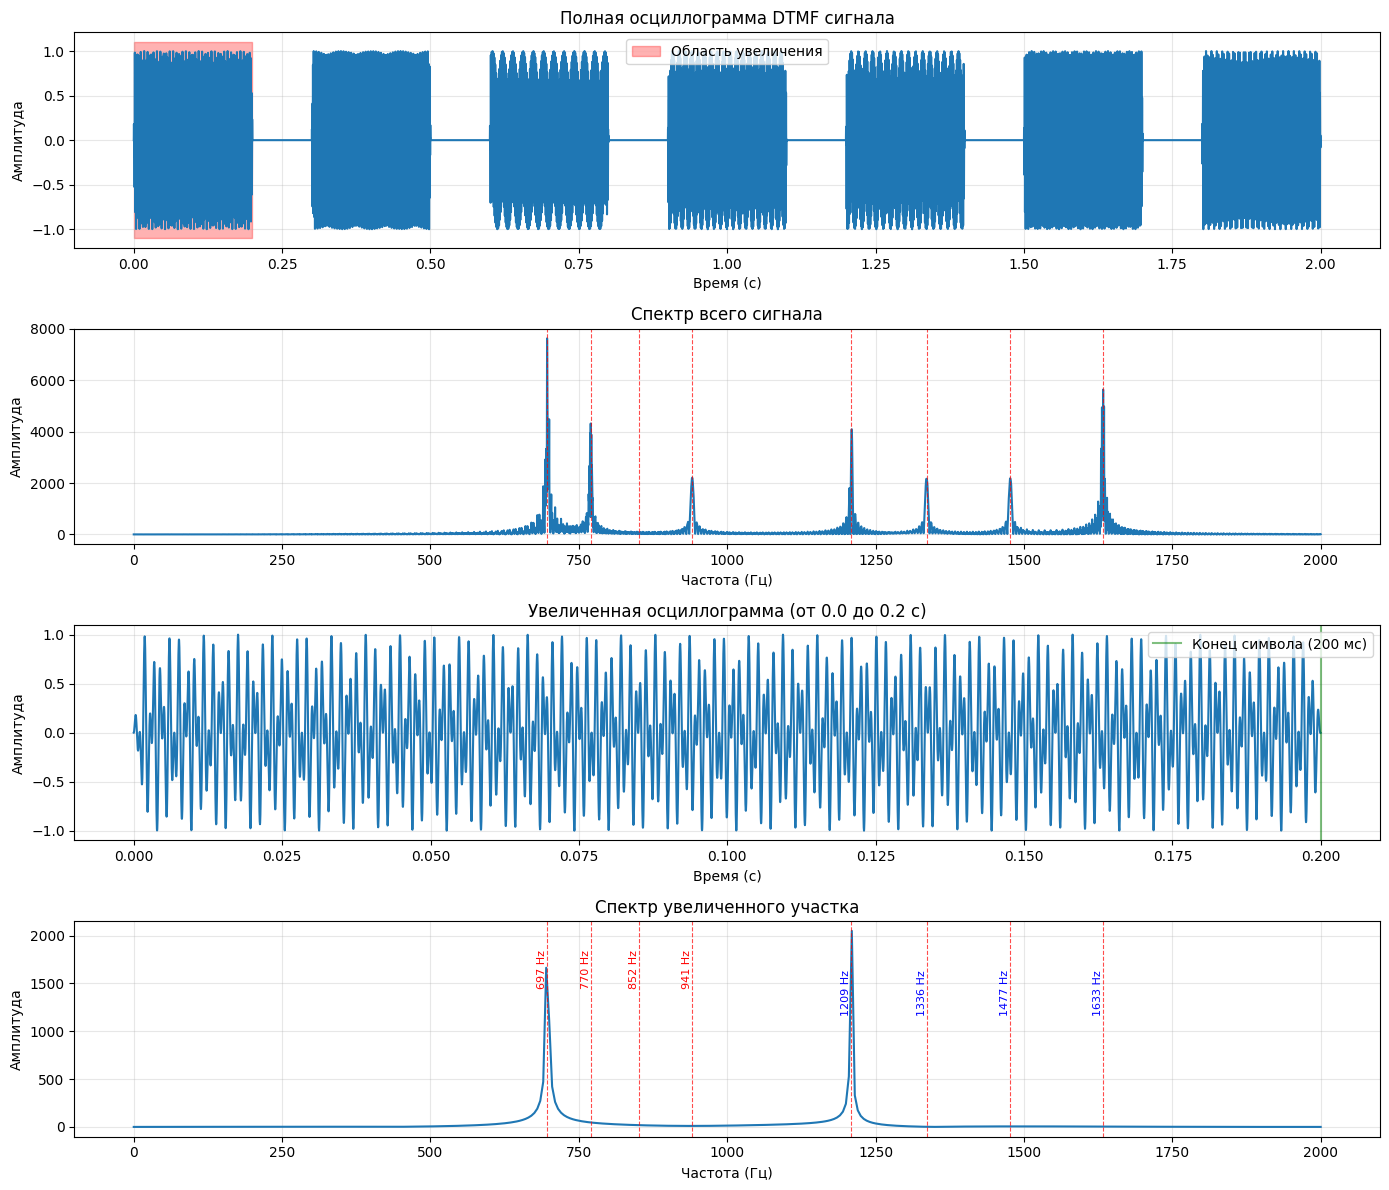

Частота дискретизации: 44100 Hz
Длительность полного сигнала: 2.00 с
Длительность увеличенного участка: 0.2 с
DTMF частоты: низкие [697, 770, 852, 941] Hz, высокие [1209, 1336, 1477, 1633] Hz


In [ ]:
print("Визуализация DTMF сигнала:")
plot_signal_and_spectrum(file_path, zoom_start=0.0, zoom_duration=0.20)

In [ ]:
print("Декодирование DTMF последовательности:")
decoded_sequence = decode_dtmf_signal(file_path, threshold_ratio=0.1)
print(f"Распознанная последовательность: {decoded_sequence}")

print(f"\nКоличество распознанных символов: {len(decoded_sequence)}")
print(f"Длина последовательности: {len(decoded_sequence)}")

Декодирование DTMF последовательности:
Распознанная последовательность: 1A2B3D4C5*6*7#8#

Количество распознанных символов: 16
Длина последовательности: 16


## Тестирование алгоритма на различных порогах

In [ ]:
print("Тестирование с различными порогами:")
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25]

for threshold in thresholds:
    sequence = decode_dtmf_signal(file_path, threshold_ratio=threshold)
    print(f"Порог {threshold}: {sequence}")

Тестирование с различными порогами:
Порог 0.05: 1A2B3D4C5*6*7#8#
Порог 0.1: 1A2B3D4C5*6*7#8#
Порог 0.15: 1A2B3D4C5*6*7#8#
Порог 0.2: 1A2B3D4C5*6*7#8#
Порог 0.25: 1A2B3D4C5*6*7#8#
